In [192]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil


In [193]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [194]:
C = Config()

C.G = 1
C.linear_net = True
C.learning_rate = .1
C.L=0
C.print_progress = True
C.length_corridors = [9]*1
C.max_move = 9
C.hidden_size = C.length_corridors[0] * 3 - 1
C.num_epochs = 100000
C.algo_name = 'SGD'
C.loss_fn = nn.CrossEntropyLoss()
C.bias = False
C.allow_backwards = True

# var_name = 'G'
# var_values = [0.1, 1, 10]
var_name = 'max_move'
var_values = np.arange(C.length_corridors[0])
# var_values = np.arange(6, 16)

In [195]:


# Ensure the results directory exists
results_dir = f'results/notebook_results/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{var_value}.pkl')
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value) for var_value in var_values
)

# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

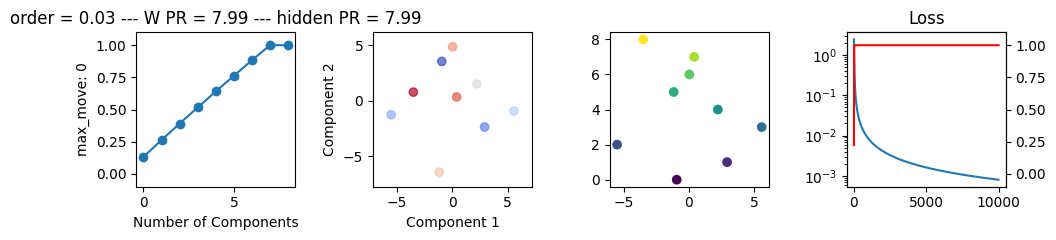

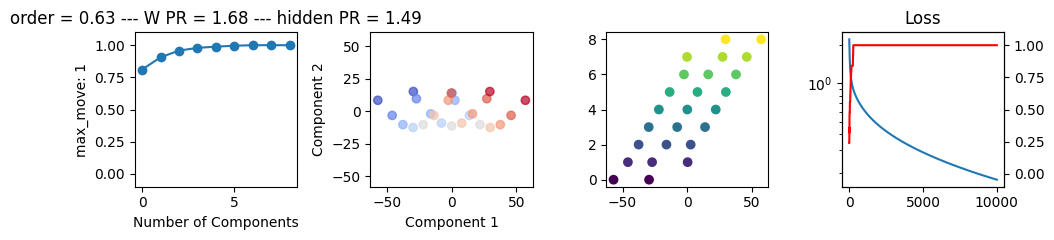

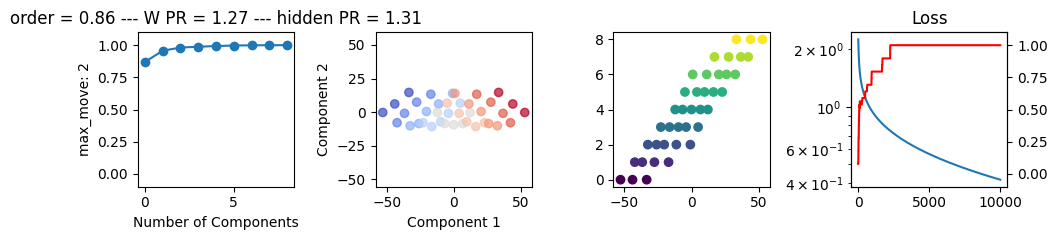

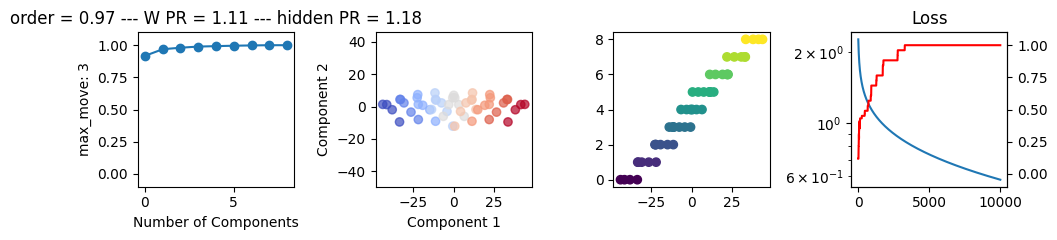

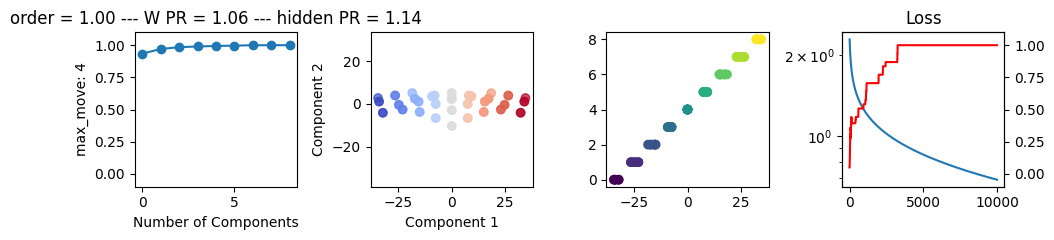

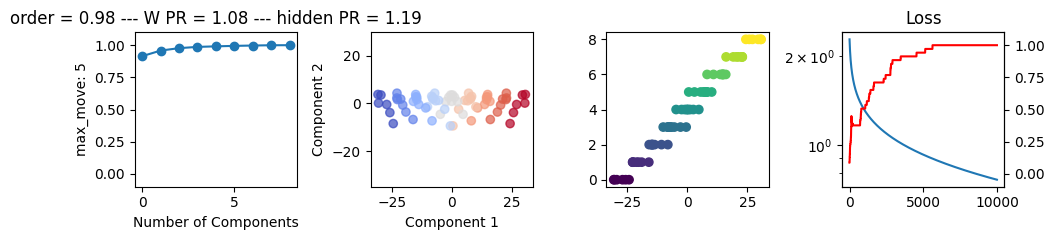

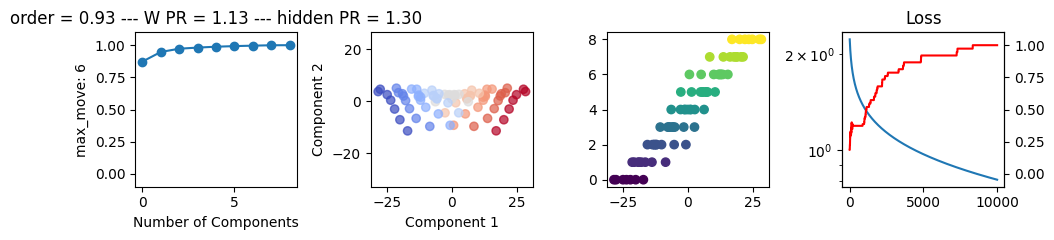

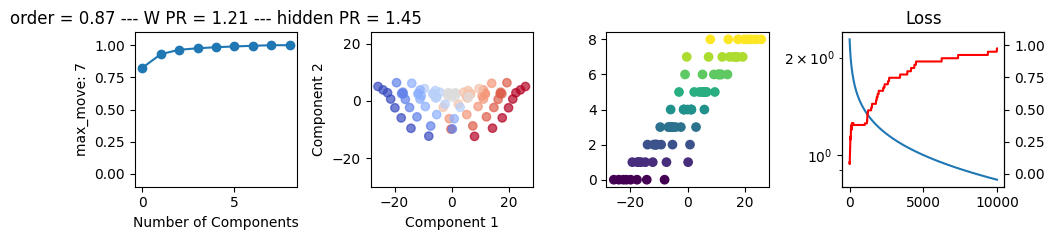

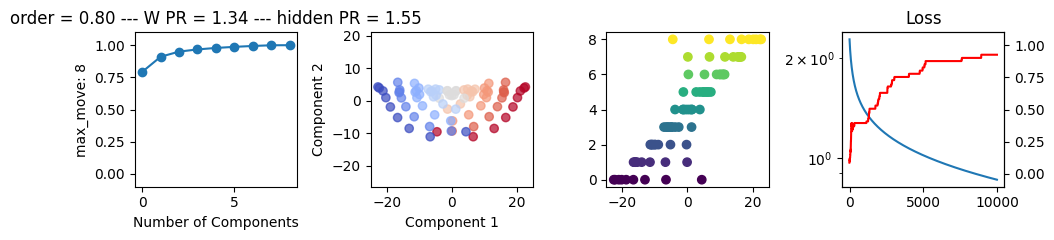

In [196]:
for data_dict in data_dict_l:
    plot_pca(data_dict, title=f'{var_name}: {getattr(data_dict["C"], var_name)}')

Accuracy: 0.7540983606557377


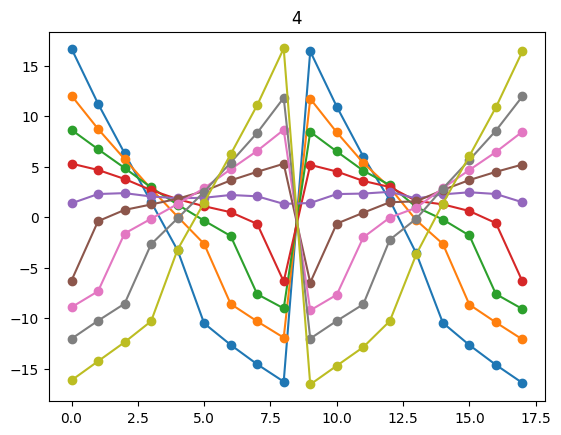

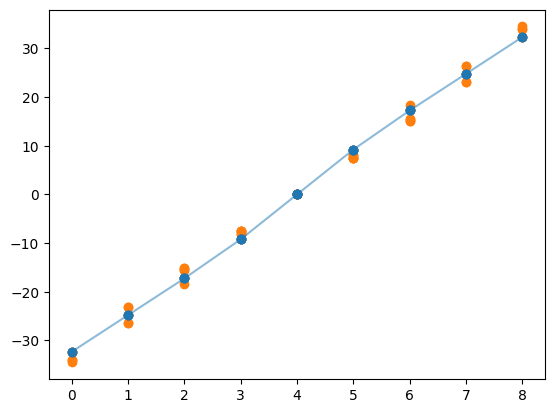

(-37.968787002563474,
 37.96972541809082,
 -0.05500000000000001,
 0.05500000000000001)

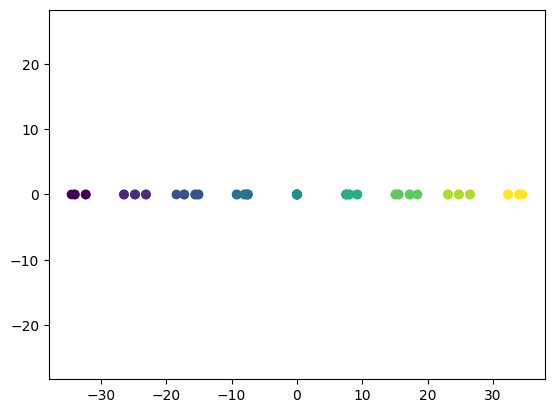

In [217]:
data_dict = data_dict_l[4]
X = data_dict['X'].cpu().numpy()
y = data_dict['y'].cpu().numpy().argmax(1)
W = get_effective_W_from_model_dict(data_dict['final_weights'])
W = W.cpu().numpy()
np.linalg.matrix_rank(W, tol=1)

U, S, V = np.linalg.svd(W, full_matrices=False)
r = 5
W_rec = U[:,:r] @ np.diag(S[:r]) @ V[:r,:]
print(f'Accuracy: {((X@W_rec).argmax(1)==y).mean()}')
plt.plot(W, marker='o')
plt.title(data_dict['C'].max_move)
plt.show()

plt.plot(data_dict['loc_X'], X[:,:C.length_corridors[0]]@U[:C.length_corridors[0],0]*S[0], marker='o', alpha=0.5)
plt.scatter(data_dict['loc_y'], X@U[:,0]*S[0], marker='o', c='tab:orange')
plt.show()


plt.scatter(X@U[:,0]*S[0], np.zeros(X.shape[0]), marker='o', c=data_dict['loc_y'])
plt.axis('equal')

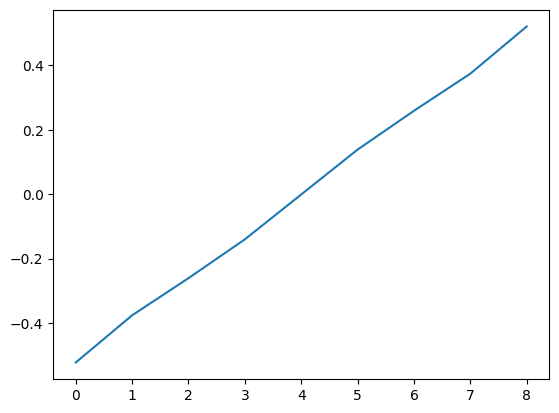

In [218]:
plt.plot(V[0])

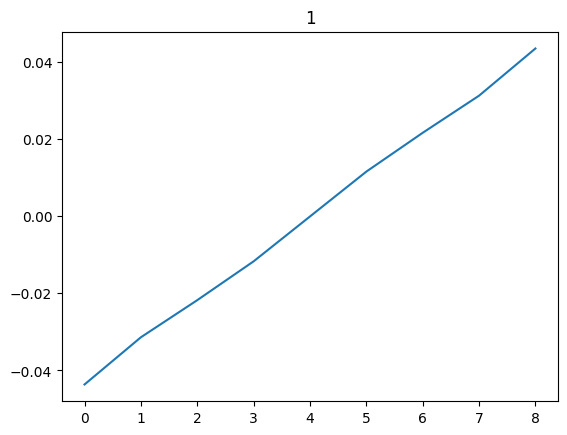

In [229]:
i = 10
plt.title(f'{loc_y[i]}')
plt.plot((X@U[:,[0]]@V[[0]])[i])

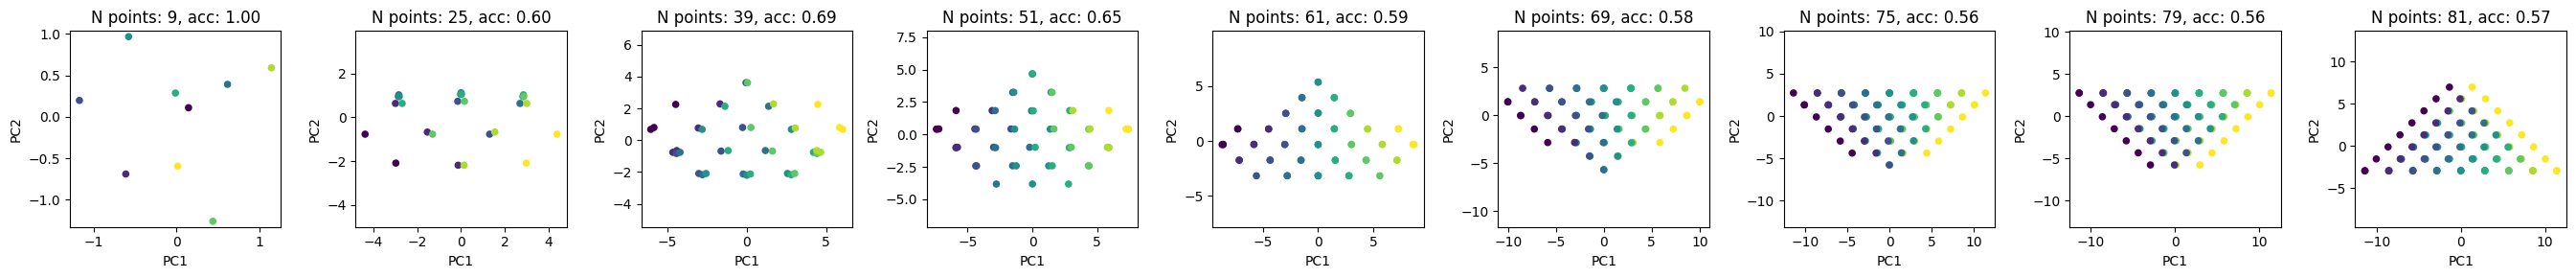

In [200]:
fig = plt.figure(figsize=(len(data_dict_l)*3, 3))
axs = []
for i in range(len(data_dict_l)):
    ax = fig.add_subplot(1, len(data_dict_l), i+1)
    axs.append(ax)

for i, data_dict in enumerate(data_dict_l):
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy().argmax(1)
    loc_y = data_dict['loc_y']
    from sklearn.svm import LinearSVC

    # Train a linear multiclass SVM
    svm = LinearSVC(C=1e6, multi_class='ovr', fit_intercept=False, max_iter=10000)
    svm.fit(X, y)

    # Compute functional margins for each sample
    W = svm.coef_.T  # shape (n_classes, n_features)
    U, S, V = np.linalg.svd(W, full_matrices=False)
    hidden = X@U@np.diag(S)
    acc = ((X@W).argmax(1)==y).mean()

    # Use 2D PCA
    hidden_pca = PCA(n_components=2).fit_transform(hidden)
    axs[i].scatter(hidden_pca[:,0], hidden_pca[:,1], c=loc_y, s=20)
    axs[i].set_xlabel('PC1')
    axs[i].set_ylabel('PC2')
    axs[i].set_title(f'N points: {X.shape[0]}, acc: {acc:.2f}')
    axs[i].axis('equal')
plt.tight_layout()
plt.show()